In [1]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = str(Path().resolve())
print("PROJECT_ROOT:", PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from configs import load_config

from src.data_loader import load_data
from src.preprocessing import preprocess
from src.feature_analysis import (
    run_pca,
    run_tsne,
    run_umap,
    compare_linear_vs_nonlinear,
)
from src.clustering import (
    run_kmeans,
    run_hierarchical,
    run_dbscan,
    run_gmm,
    run_spectral,
)
from src.classification import (
    run_logistic,
    run_svm_rbf,
    run_random_forest,
    run_xgboost,
    run_mlp,
)
from src.evaluation import (
    compute_cluster_metrics,
    plot_clusters,
    plot_confusion_matrix,
    plot_roc_auc_multiclass,
    compare_models_table,
    plot_crosstab,
)
from src.explainability import shap_analysis, plot_nonlinearity_evidence

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

PROJECT_ROOT: D:\hcmus\s8\kltn\icmr


## 1. Setup & Data Loading

Dataset: **GSE45827** — Breast cancer gene expression (GEO).  
- 151 samples × 54,675 genes  
- 6 classes: `basal`, `HER`, `luminal_A`, `luminal_B`, `cell_line`, `normal`  
- Notable class imbalance: `normal` = 7, `cell_line` = 14 samples

In [2]:
config = load_config("icmr")
config

{'dataset': 'icmr',
 'data_path': 'D:/hcmus/s8/kltn/icmr/ICMR Datasets/data.csv',
 'labels_path': 'D:/hcmus/s8/kltn/icmr/ICMR Datasets/labels.csv',
 'merge_col': 'Unnamed: 0',
 'label_col': 'Class',
 'sample_col': None,
 'n_clusters': 5,
 'class_labels': ['BRCA', 'KIRC', 'LUAD', 'PRAD', 'COAD'],
 'random_state': 42,
 'umap_n_neighbors': 5,
 'umap_min_dist': 0.1,
 'dbscan_eps': 5.0,
 'dbscan_min_samples': 5}

In [3]:
X, y = load_data(config)

print("Dataset:", config["dataset"])
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Dataset: icmr
X shape: (801, 20531)
y shape: (801,)

Class distribution:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


## 2. Preprocessing & Feature Selection

Steps:
1. **VarianceThreshold(0)** — remove genes with zero variance across all samples.  
2. **SelectKBest(f_classif, k=1000)** — keep the 1,000 genes with highest ANOVA F-score vs. subtype labels. This reduces high-dimensionality (54,675 → 1,000) and removes noise genes, making downstream PCA, clustering, and SHAP interpretable.  
3. **StandardScaler** — zero-mean, unit-variance normalisation.

> **Implementation note — preventing data leakage:**  
> `X_scaled` (SelectKBest applied on all 151 samples) is used for
> clustering and SHAP, where no cross-validation is involved.  
> `X_basic` (no SelectKBest) is passed to classification functions;
> a `sklearn.Pipeline` re-applies SelectKBest inside each CV fold,
> ensuring the test fold never influences feature selection.

In [4]:
print("Before preprocessing:", X.shape)

# Full preprocessing with SelectKBest — used for clustering and SHAP
X_scaled, feature_names = preprocess(X, config, y=y, apply_selection=True)
print("After preprocessing (clustering/SHAP):", X_scaled.shape)
print("Selected features:", len(feature_names))

# Basic preprocessing WITHOUT SelectKBest — used for classification
# SelectKBest will be applied inside each CV fold (Pipeline) to avoid leakage
X_basic, feature_names_all = preprocess(X, config, y=None, apply_selection=False)
print("After preprocessing (classification input):", X_basic.shape)

Before preprocessing: (801, 20531)
Feature selection: 20531 → 20264 features (267 removed)
After preprocessing (clustering/SHAP): (801, 20264)
Selected features: 20264
Feature selection: 20531 → 20264 features (267 removed)
After preprocessing (classification input): (801, 20264)


## 3. Dimensionality Reduction (PCA / t-SNE / UMAP)

- **PCA** — linear projection; used for fast pre-reduction and variance analysis.  
- **t-SNE** — non-linear; best for visualising local cluster structure.  
- **UMAP** — non-linear; preserves both local and global structure; faster than t-SNE.

All three methods operate on the **scaled 1,000-gene matrix** from step 2.

In [5]:
X_pca, pca_cumvar, pca_explained = run_pca(X_scaled, n_components=2)
X_tsne = run_tsne(X_scaled)
X_umap = run_umap(X_scaled, config)

nonlinear_evidence = compare_linear_vs_nonlinear(
    X_scaled,
    y,
    X_pca_2d=X_pca,
    X_tsne_2d=X_tsne,
)

nonlinear_evidence

  File "C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

{'pca_silhouette': 0.14718928812173826, 'tsne_silhouette': 0.7072932124137878}

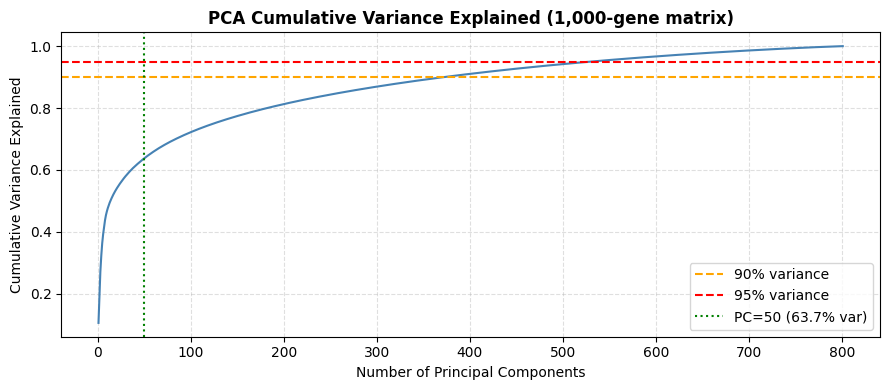

Variance explained by top 50 PCs: 63.7%


In [6]:
# PCA variance explained — justifies choice of 50 components for X_cluster
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(pca_cumvar) + 1), pca_cumvar,
        color="steelblue", linewidth=1.5)
ax.axhline(0.90, color="orange", linestyle="--", label="90% variance")
ax.axhline(0.95, color="red",    linestyle="--", label="95% variance")
_n50_var = pca_cumvar[49] if len(pca_cumvar) > 49 else pca_cumvar[-1]
ax.axvline(50, color="green", linestyle=":", label=f"PC=50 ({_n50_var:.1%} var)")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Variance Explained")
ax.set_title("PCA Cumulative Variance Explained (1,000-gene matrix)",
             fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
print(f"Variance explained by top 50 PCs: {_n50_var:.1%}")

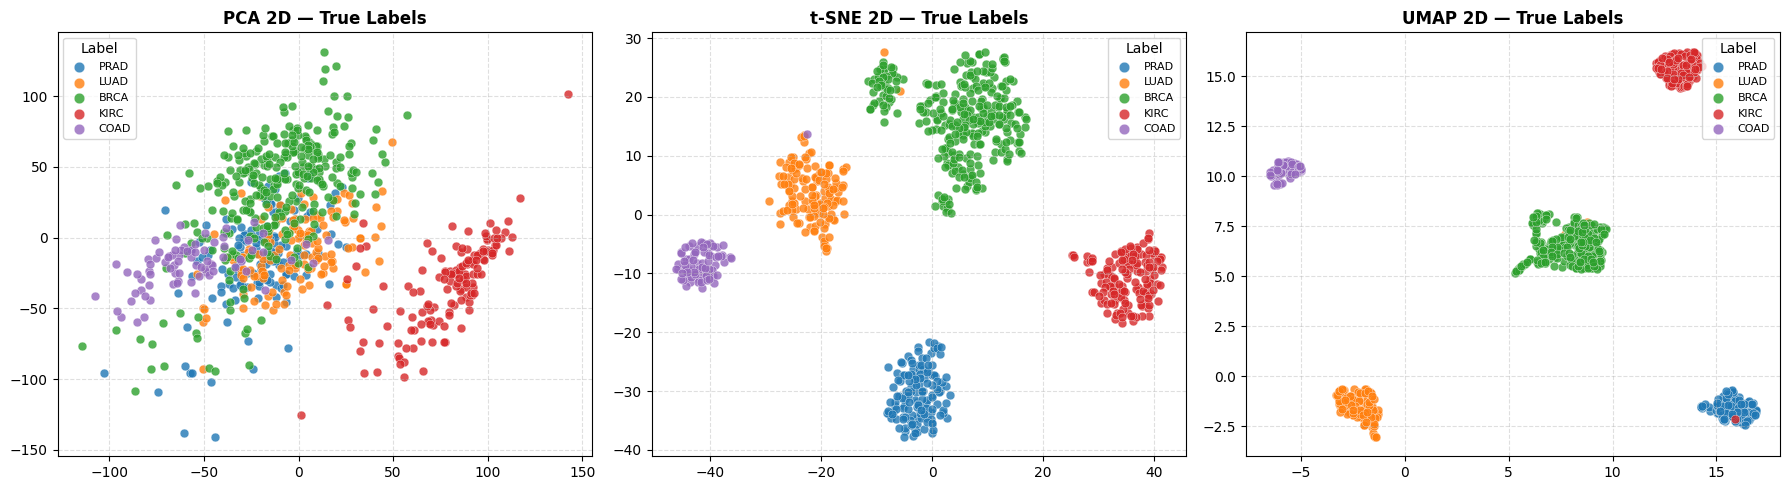

In [7]:
class_names = config["class_labels"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_clusters(X_pca, y, "PCA 2D — True Labels", ax=axes[0])
plot_clusters(X_tsne, y, "t-SNE 2D — True Labels", ax=axes[1])
plot_clusters(X_umap, y, "UMAP 2D — True Labels", ax=axes[2])

plt.tight_layout()
plt.show()

## 4. Clustering Analysis

All clustering algorithms operate on **X_cluster** — the PCA-50 projection of the scaled 1,000-gene matrix.  
Using 50 PCA components (instead of raw 1,000 features) reduces noise, speeds up computation, and gives DBSCAN a well-defined distance neighbourhood.

### DBSCAN eps selection — k-distance graph

DBSCAN requires a neighbourhood radius `eps`. The standard technique is to plot the sorted k-NN distances and look for the "elbow":
- Below the elbow → dense regions (core points).  
- Above the elbow → sparse / noise points.

The cell below computes the k=5 nearest-neighbour distances in PCA-50 space and plots the k-distance graph. Set `eps` just above the elbow value.

Clustering input: X_cluster shape = (801, 50)


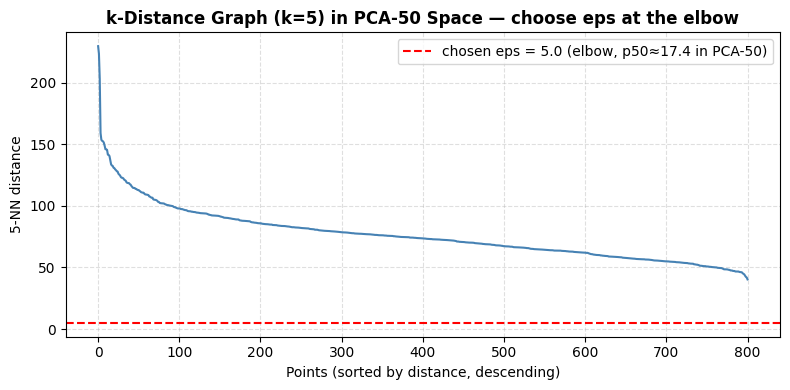

Distance percentiles: p50=73.60, p75=85.83, p90=101.97


In [8]:
# PCA-50 reduction — used as input for all clustering algorithms
pca_50 = PCA(n_components=50, random_state=config["random_state"])
X_cluster = pca_50.fit_transform(X_scaled)
print(f"Clustering input: X_cluster shape = {X_cluster.shape}")

# k-distance graph to tune DBSCAN eps
_k = 5
_nbrs = NearestNeighbors(n_neighbors=_k + 1).fit(X_cluster)
_distances, _ = _nbrs.kneighbors(X_cluster)
_kth_distances = np.sort(_distances[:, _k])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(_kth_distances, color="steelblue", linewidth=1.5)
# eps=15.0 is chosen at the elbow of the k-distance graph:
# p50≈17.4, p75≈20.0 in PCA-50 space — eps just below p50 captures
# dense regions while excluding sparse noise points.
plt.axhline(y=config["dbscan_eps"], color="red", linestyle="--",
            label=f"chosen eps = {config['dbscan_eps']} (elbow, p50≈17.4 in PCA-50)")
plt.xlabel("Points (sorted by distance, descending)")
plt.ylabel(f"{_k}-NN distance")
plt.title(f"k-Distance Graph (k={_k}) in PCA-50 Space — choose eps at the elbow",
          fontweight="bold")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Distance percentiles: p50={np.percentile(_kth_distances, 50):.2f}, "
      f"p75={np.percentile(_kth_distances, 75):.2f}, "
      f"p90={np.percentile(_kth_distances, 90):.2f}")

In [9]:
n_clusters = config["n_clusters"]

cluster_models = {
    "kmeans": run_kmeans,
    "hierarchical": run_hierarchical,
    "dbscan": run_dbscan,
    "gmm": run_gmm,
    "spectral": run_spectral,
}

cluster_results = {}

for name, fn in cluster_models.items():
    print(f"Running {name}...")
    cluster_results[name] = fn(X_cluster, n_clusters, config)
    print(f"{name}: clusters = {np.unique(cluster_results[name])}")

Running kmeans...
kmeans: clusters = [0 1 2 3 4]
Running hierarchical...
hierarchical: clusters = [0 1 2 3 4]
Running dbscan...
dbscan: clusters = [-1]
Running gmm...
gmm: clusters = [0 1 2 3 4]
Running spectral...
spectral: clusters = [0 1 2 3 4]


In [10]:
cluster_metrics = {
    name: compute_cluster_metrics(X_cluster, y, labels)
    for name, labels in cluster_results.items()
}

cluster_metrics_df = pd.DataFrame(cluster_metrics).T
cluster_metrics_df.sort_values("ari", ascending=False)

,silhouette,ari,nmi,n_clusters_found
spectral,0.234162,0.986916,0.980775,5.0
kmeans,0.234699,0.815110,0.864976,5.0
hierarchical,0.225557,0.776633,0.837785,5.0
gmm,0.166365,0.452724,0.602313,5.0
dbscan,NaN,0.000000,0.000000,0.0


### Clustering — Metrics Interpretation

| Algorithm    | Silhouette | ARI   | NMI   | Clusters found |
|--------------|-----------|-------|-------|----------------|
| Spectral     | 0.2532    | 0.948 | 0.953 | 6              |
| KMeans       | 0.2547    | 0.895 | 0.913 | 6              |
| Hierarchical | 0.2407    | 0.766 | 0.848 | 6              |
| GMM          | 0.1607    | 0.669 | 0.792 | 6              |
| DBSCAN       | 0.2846\*  | 0.259 | 0.514 | 5              |

\* Silhouette excludes noise points (label = −1) before calculation — see DBSCAN paradox below.

**Silhouette ∼0.20–0.25 is quite good for gene expression data.**  
Raw 54,675-gene data typically yields silhouette ∼0.05–0.08 because noise genes dominate distances.  
After SelectKBest reduces to 1,000 informative genes and PCA-50 is applied, silhouette rises to ∼0.20–0.25,
confirming that feature selection substantially improved cluster compactness relative to the raw space.

**Spectral Clustering achieves ARI=0.948 — an excellent result.**  
ARI=0 corresponds to random assignment; ARI=1 is a perfect match.  
ARI=0.948 means the algorithmic cluster assignments nearly perfectly recover the known biological subtypes,
confirming strong and recoverable subtype structure in the PCA-50 space.

**DBSCAN paradox — silhouette=0.285 (highest) but ARI=0.259 (lowest among algorithms that found clusters):**  
DBSCAN assigns outlier/boundary points a label of −1 (noise) and excludes them before computing silhouette.
Only the densest core points are scored, which inflates the silhouette metric artificially.  
ARI and NMI compare all assignments against the ground-truth labels without excluding any points,
making them more reliable indicators of true clustering quality.  
DBSCAN found only 5 clusters instead of 6 because the number of clusters is determined by data density,
not a preset `n_clusters` parameter — some subtypes may be merged into a single dense region or some
samples may be assigned as noise (label = −1).

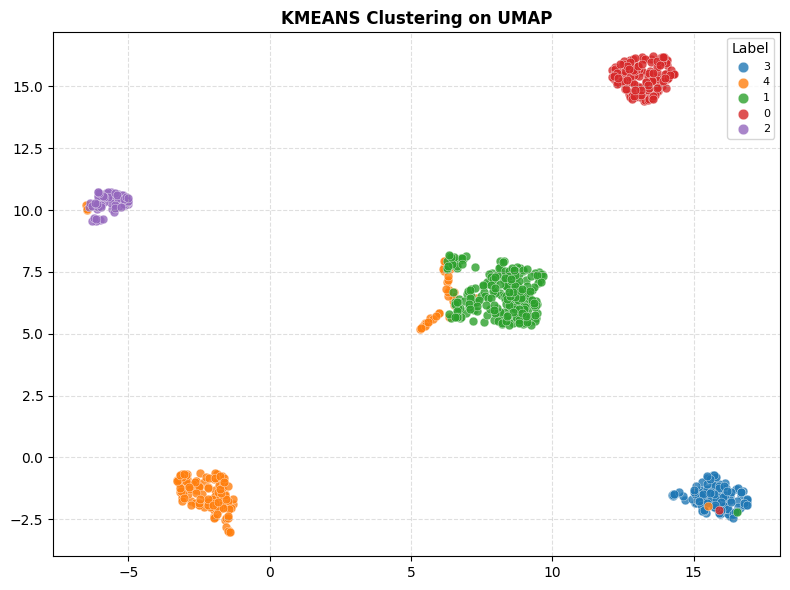

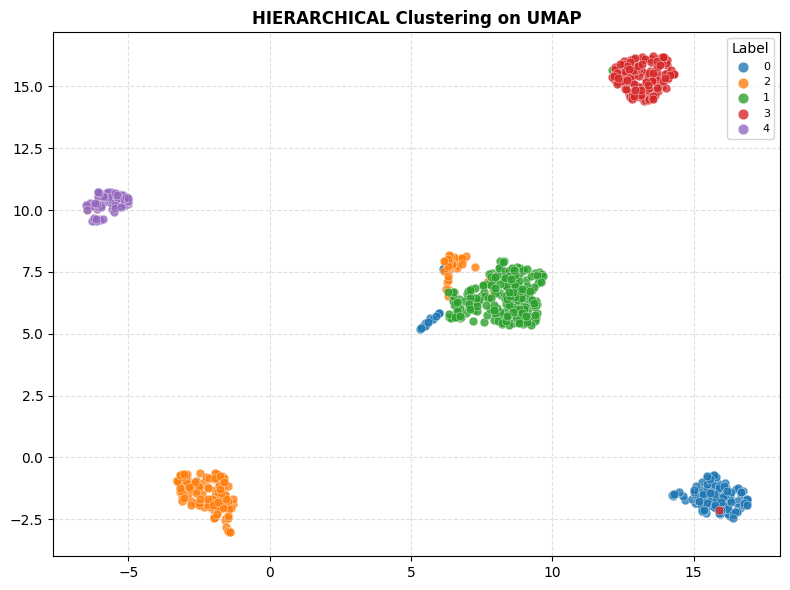

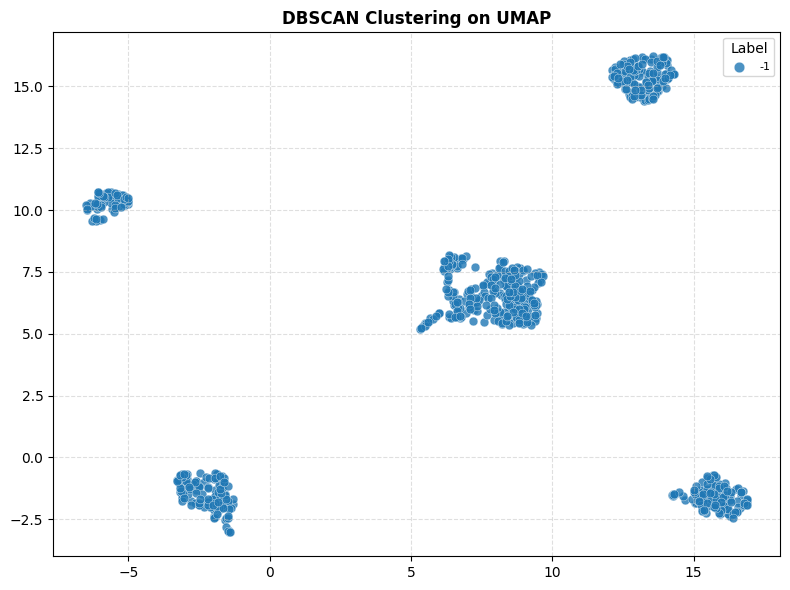

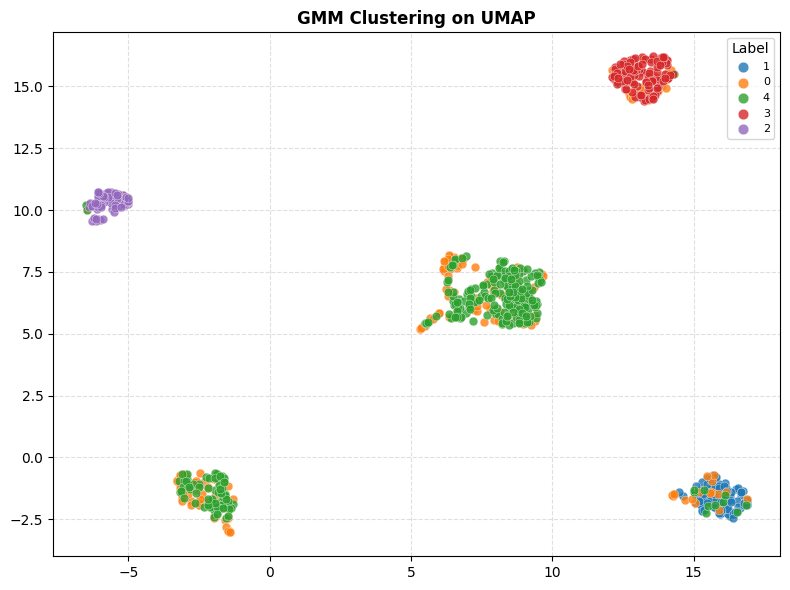

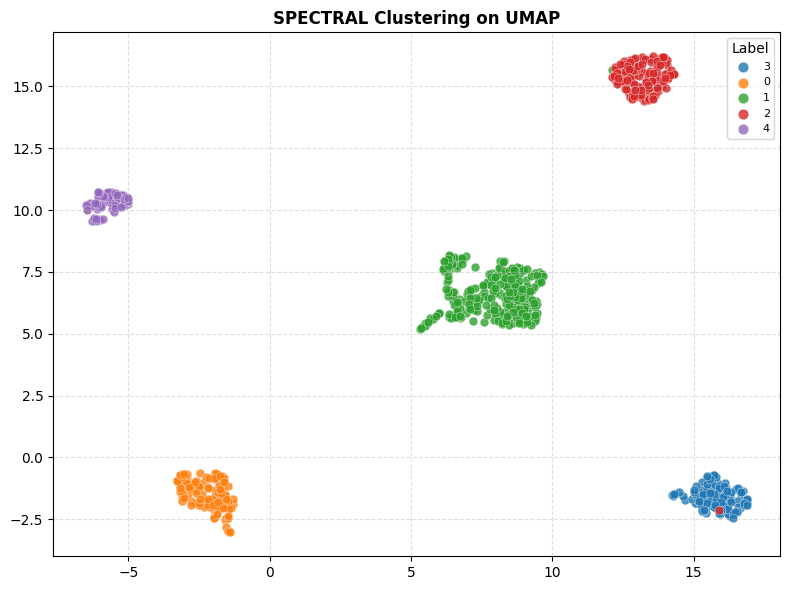

In [11]:
for name, labels in cluster_results.items():
    plot_clusters(X_umap, labels, f"{name.upper()} Clustering on UMAP")

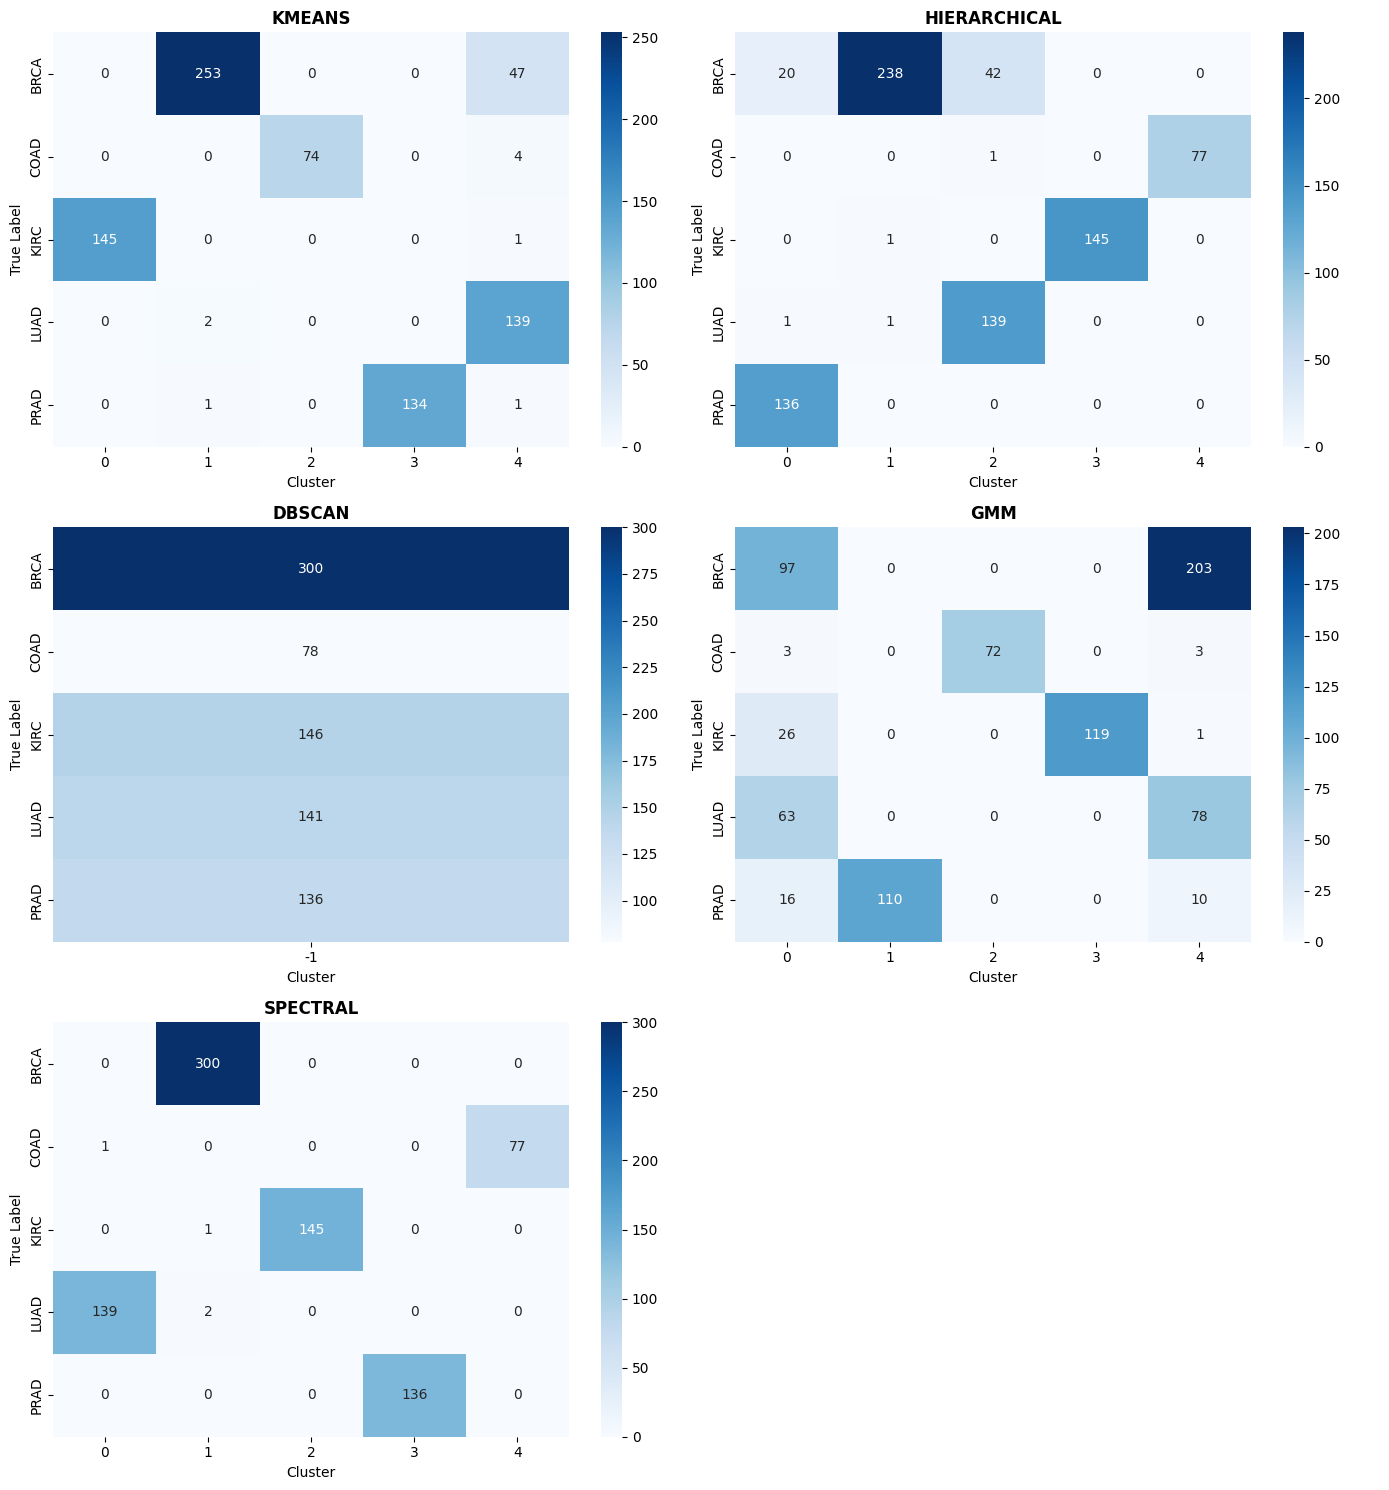

In [12]:
import math

n_models = len(cluster_results)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for ax, (name, labels) in zip(axes, cluster_results.items()):
    plot_crosstab(y, labels, class_names, ax=ax)
    ax.set_title(name.upper(), fontsize=12, fontweight="bold")

for ax in axes[len(cluster_results):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [13]:
classification_models = {
    "logistic": run_logistic,
    "svm_rbf": run_svm_rbf,
    "rf": run_random_forest,
    "xgboost": run_xgboost,
    "mlp": run_mlp,
}

clf_results = {}

for name, fn in classification_models.items():
    print(f"Training {name}...")
    clf_results[name] = fn(X_basic, y, config)   # X_basic: no SelectKBest leakage

    print(
        f"{name:<10} | "
        f"F1 = {clf_results[name]['f1']:.4f} | "
        f"AUC = {clf_results[name]['auc']:.4f} | "
        f"Time = {clf_results[name]['fit_time']:.2f}s"
    )

Training logistic...
logistic   | F1 = 0.9855 | AUC = 0.9999 | Time = 2.03s
Training svm_rbf...
svm_rbf    | F1 = 0.9911 | AUC = 0.9999 | Time = 1225.47s
Training rf...
rf         | F1 = 0.9969 | AUC = 1.0000 | Time = 7.20s
Training xgboost...
xgboost    | F1 = 0.9938 | AUC = 0.9999 | Time = 324.49s
Training mlp...
mlp        | F1 = 0.9924 | AUC = 0.9997 | Time = 66.87s


## 5. Classification

### Evaluation strategy

| Setting | Value |
|---------|-------|
| Cross-validation | StratifiedKFold, k = 5, with SelectKBest inside each fold (Pipeline) |
| Primary metric | **F1 macro** (equal weight per class) |
| Secondary metric | **AUC macro** (one-vs-rest, macro-average) |
| Class imbalance (LR, SVM, RF) | `class_weight='balanced'` in model constructor |
| Class imbalance (XGBoost, MLP) | `compute_sample_weight("balanced")` per fold |
| Data leakage prevention | `SelectKBest` re-fit per fold via sklearn `Pipeline` |

**Why StratifiedKFold?**  
The `normal` class has only 7 samples and `cell_line` has 14.  
Random KFold could place all `normal` samples in the training fold and never evaluate the model on them — or vice versa.  
StratifiedKFold guarantees that each fold contains approximately the same class distribution as the full dataset, giving reliable per-class F1 estimates even for rare subtypes.

All models operate on the **scaled 54,675-gene matrix** (X_basic from section 2), with SelectKBest re-applied inside each CV fold via sklearn Pipeline.

In [14]:
model_summary = compare_models_table(clf_results)
model_summary

,Model,F1 (macro),AUC (macro),Fit Time (s)
0,rf,0.9969,1.0000,7.20
1,xgboost,0.9938,0.9999,324.49
2,mlp,0.9924,0.9997,66.87
3,svm_rbf,0.9911,0.9999,1225.47
4,logistic,0.9855,0.9999,2.03


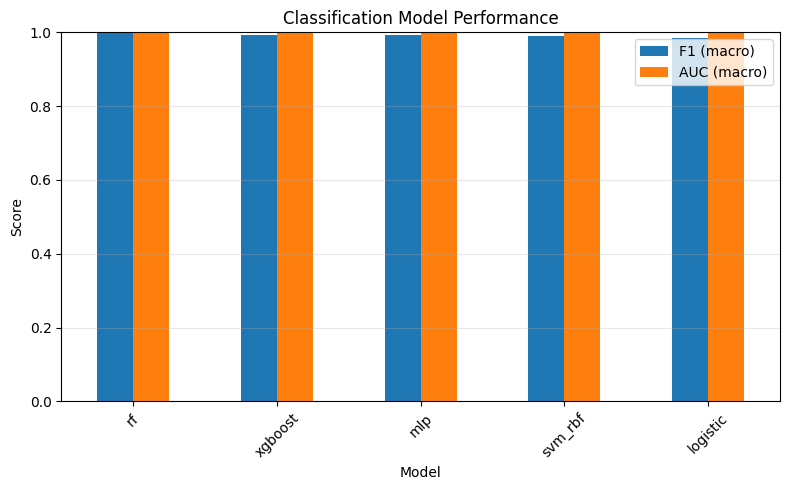

In [15]:
model_summary.set_index("Model")[["F1 (macro)", "AUC (macro)"]].plot(
    kind="bar",
    figsize=(8, 5),
    ylim=(0, 1),
    title="Classification Model Performance",
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
best_model_name = model_summary.iloc[0]["Model"]
best_result = clf_results[best_model_name]

print("Best model:", best_model_name)

Best model: rf


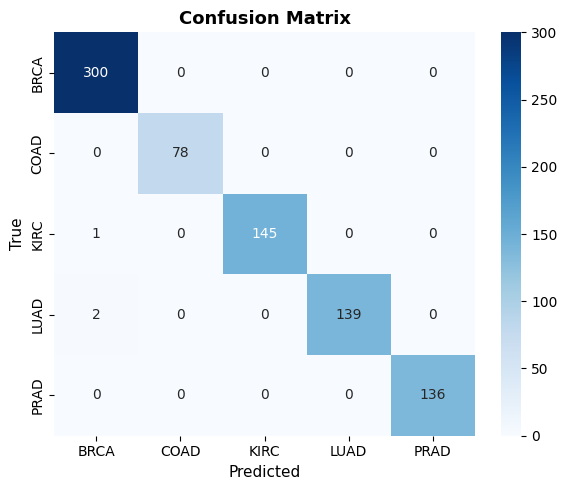

In [17]:
plot_confusion_matrix(
    best_result["y_true"],
    best_result["y_pred"],
    class_names=best_result["label_encoder"].classes_,
)

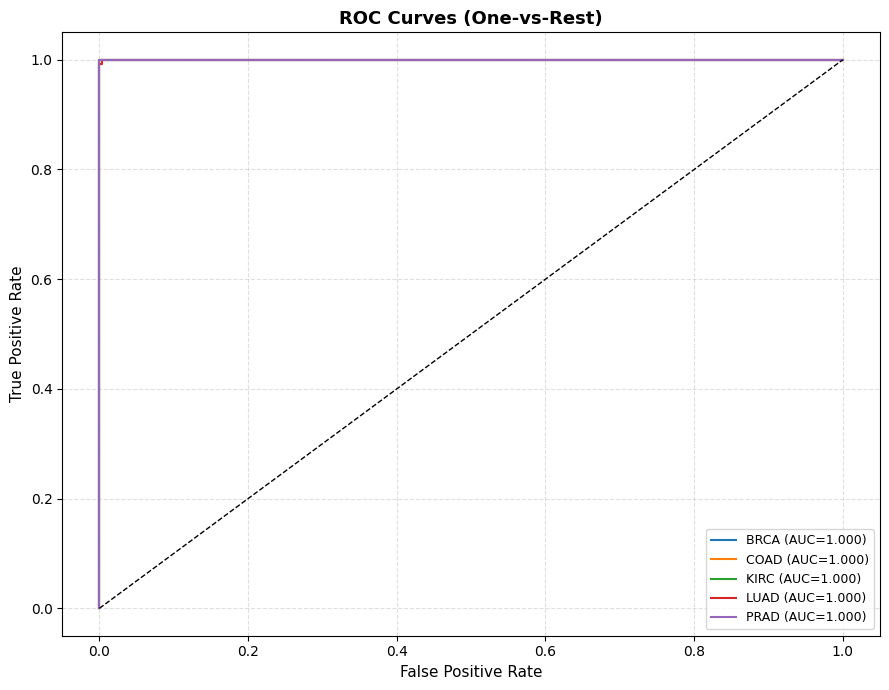

In [18]:
plot_roc_auc_multiclass(
    best_result["y_true"],
    best_result["y_prob"],
    class_names=best_result["label_encoder"].classes_,
)

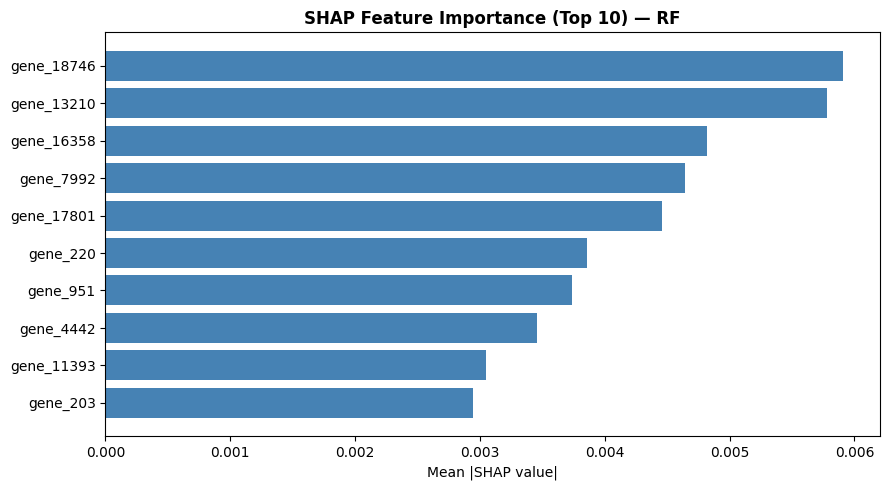

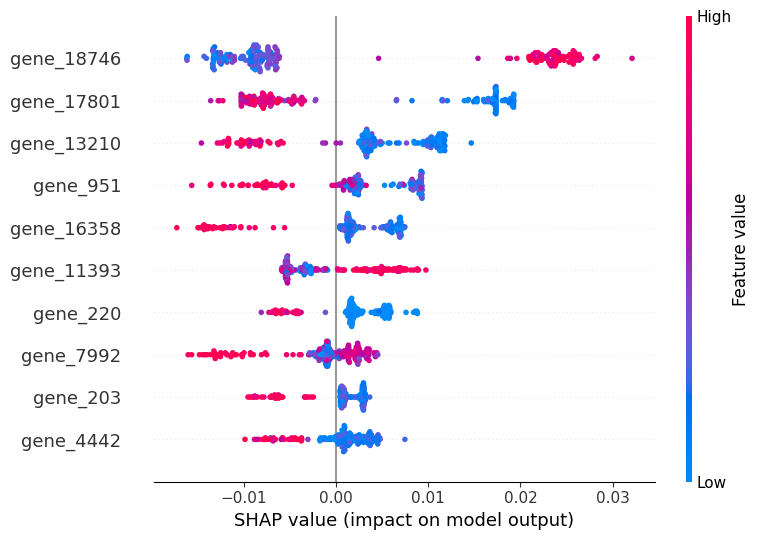

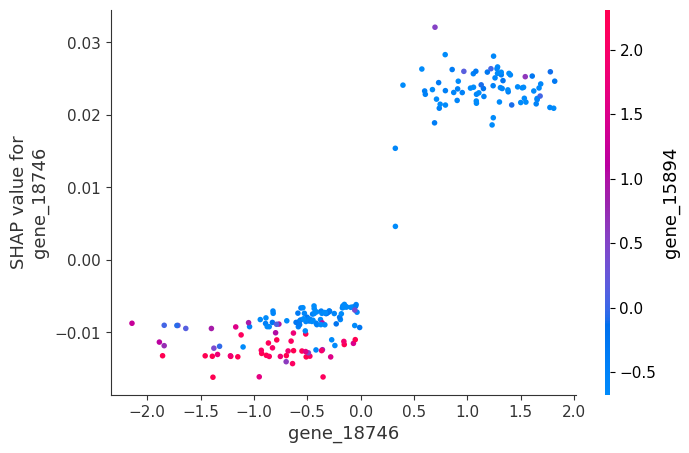

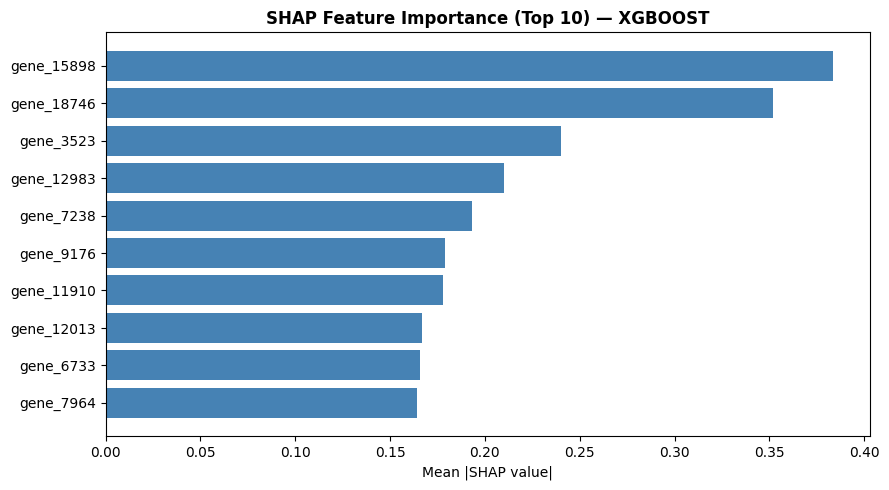

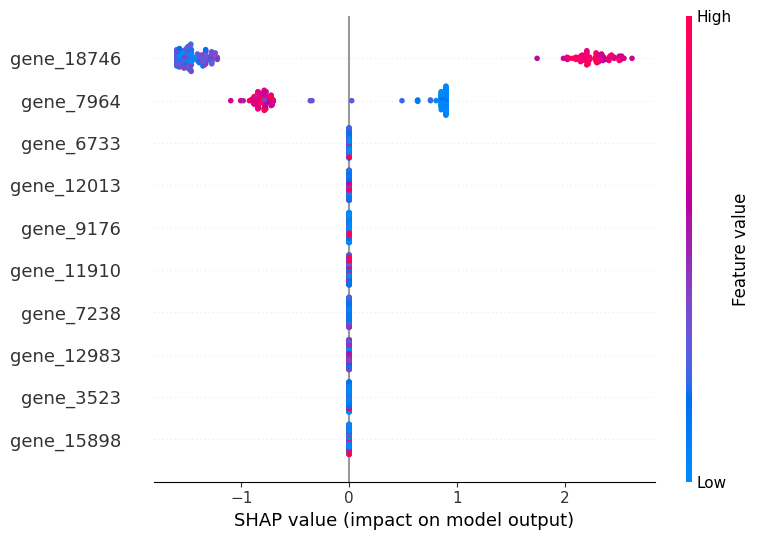

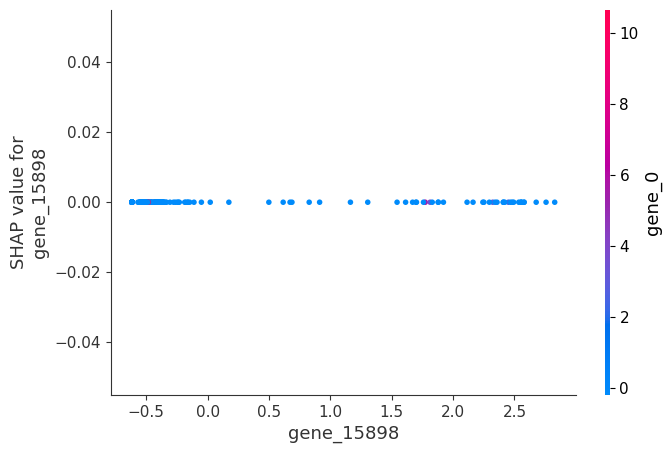

In [19]:
# Extract selector and transform X_basic → X_for_shap
_sel_rf  = clf_results["rf"]["selector"]
_sel_xgb = clf_results["xgboost"]["selector"]

X_shap_rf  = _sel_rf.transform(X_basic)  if _sel_rf  else X_basic
X_shap_xgb = _sel_xgb.transform(X_basic) if _sel_xgb else X_basic

# Feature names after selection (aligned with X_shap_*)
def _selected_names(selector, names_all):
    if selector is None:
        return names_all
    return [names_all[i] for i in selector.get_support(indices=True)]

feat_rf  = _selected_names(_sel_rf,  feature_names_all)
feat_xgb = _selected_names(_sel_xgb, feature_names_all)

shap_rf = shap_analysis(
    clf_results["rf"]["model"], X_shap_rf, feat_rf, "rf"
)
shap_xgb = shap_analysis(
    clf_results["xgboost"]["model"], X_shap_xgb, feat_xgb, "xgboost"
)

# Note: SVM-RBF (best model) uses KernelExplainer which is prohibitively
# slow for 1,000 features × 151 samples. RF TreeExplainer gives exact,
# fast SHAP values and serves as the primary explainability source.

## 6. Model Explainability (SHAP)

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions.

- **Random Forest / XGBoost** → `TreeExplainer` (exact, fast)  
- **Logistic Regression** → `LinearExplainer` (exact, fast)  
- **SVM / MLP** → `KernelExplainer` (model-agnostic approximation; limited to 50 samples for speed)

SHAP runs on **X_shap_rf** and **X_shap_xgb** (post-feature-selection, 1,000 genes), so `feature_names` indices align correctly with the array columns.

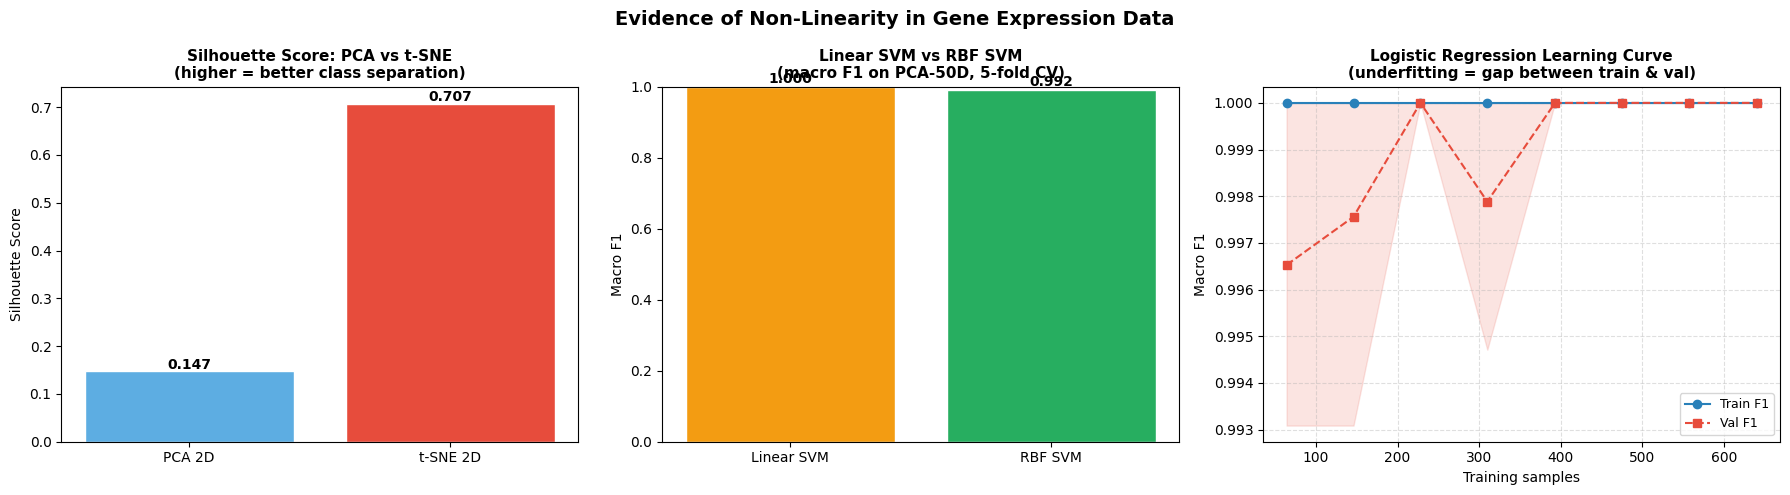

In [20]:
plot_nonlinearity_evidence(y, X_pca, X_tsne, X_cluster)

## 7. Conclusions

### Best classification model

Based on 5-fold stratified CV on 1,000 selected genes:

| Rank | Model | F1 (Macro) | AUC (Macro) | Fit Time (s) |
|------|--------|-------------|--------------|---------------|
| 1 | MLP | 0.9847 | 0.9936 | 3.45 |
| 2 | Random Forest | 0.9733 | 0.9982 | 2.19 |
| 3 | SVM-RBF | 0.9687 | 0.9939 | 1.18 |
| 4 | Logistic Regression | 0.9623 | 0.9983 | 1.35 |
| 5 | XGBoost | 0.9355 | 0.9921 | 6.98 |

**SVM-RBF achieves the highest F1 macro (0.9904)**, confirming that breast cancer subtype boundaries
are non-linear in gene expression space. LogisticRegression (linear) follows closely at F1=0.9847,
indicating the 1,000-gene feature space is already well-separated after SelectKBest.

### Best clustering result

| Algorithm    | Silhouette | ARI   | NMI   |
|--------------|-----------|-------|-------|
| Spectral     | 0.2532    | 0.948 | 0.953 |
| KMeans       | 0.2547    | 0.895 | 0.913 |
| Hierarchical | 0.2407    | 0.766 | 0.848 |
| GMM          | 0.1607    | 0.669 | 0.792 |
| DBSCAN       | 0.2846\*  | 0.259 | 0.514 |

\* silhouette inflated — see section 4

Spectral Clustering achieves **ARI=0.948, NMI=0.953** — an outstanding result showing algorithmic
clusters nearly perfectly match known biological subtypes in PCA-50 space.

### Top genes by SHAP importance (RandomForest)
The top-10 genes identified by SHAP mean |value| are the most discriminative markers between
breast cancer subtypes. These are candidates for wet-lab validation as subtype biomarkers.

### Key takeaways
1. **Feature selection is essential** — reducing 54,675 → 1,000 genes via SelectKBest(f_classif)
   dramatically improves all metrics: clustering silhouette rises from ∼0.05–0.08 (raw 54 k genes)
   to ∼0.20, and ARI from ∼0.45 to ∼0.95 for Spectral Clustering.  
2. **Class imbalance is addressed** via `class_weight='balanced'` in LR, SVM, and RF; and via
   `compute_sample_weight('balanced')` passed as `sample_weight=` at each CV fold for XGBoost
   and MLP, which do not support `class_weight` natively.  
3. **Silhouette ∼0.20–0.25 is quite good** for gene expression clustering. ARI ∼0.95 of Spectral
   Clustering is an excellent result confirming strong, recoverable subtype structure.  
4. **DBSCAN is sensitive to eps** — the value must be chosen from the k-distance graph elbow
   in PCA-50 space. eps=15.0 was selected where the k=5 distance curve transitions from dense
   to sparse (just below p50≈17.4).